# most optimal skill to leran Data Analyst?

In [17]:
#importing libraries
import pandas as pd
import ast
import seaborn as sns
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading dataset
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas() # converting data into pandas 

# data clean up
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])# converting datatype from object to date time

# safely converts a string representation of a Python object into an actual Python object
df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x
)

In [18]:
df_DA_US=df[(df['job_country']=='United States')&(df['job_title']=='Data Analyst')].copy() # creating a new data frame df_DA_US  and making copy of it 


In [19]:
df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])
df_DA_US_exploded=df_DA_US.explode('job_skills')
df_DA_US_exploded[['salary_year_avg','job_skills']].head(5)


,salary_year_avg,job_skills
1681,111175.0,sql
1681,111175.0,tableau
1681,111175.0,power bi
1681,111175.0,excel
3237,120000.0,sql


In [20]:
df_DA_skills=df_DA_US_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_DA_skills=df_DA_skills.rename(columns={'count':'skill_count','median':'median_salary'})
DA_job_count=len(df_DA_US)
df_DA_skills['skills_percemt']=df_DA_skills['skill_count']/DA_job_count*100

skills_percent = 5

DA_job_count = len(df_DA_US)

df_DA_skills['skills_percent'] = (
    df_DA_skills['skill_count'] / DA_job_count * 100
)
df_DA_skills_high_demand = df_DA_skills[
    df_DA_skills['skills_percent'] > skills_percent
]

In [21]:
# Copy the column
df_technology = df['job_type_skills'].copy()

# Remove duplicates
df_technology = df_technology.drop_duplicates()

# Remove missing values
df_technology = df_technology.dropna()

# Combine all dictionaries
technology_dict = {}

for row in df_technology:
    row_dict = ast.literal_eval(row)

    for key, value in row_dict.items():
        if key in technology_dict:
            technology_dict[key] += value
        else:
            technology_dict[key] = value

# Remove duplicates from each list
for key, value in technology_dict.items():
    technology_dict[key] = list(set(value))

In [22]:
df_technology = pd.DataFrame(
    list(technology_dict.items()),
    columns=['technology', 'skills']
)

df_technology = df_technology.explode('skills')

df_technology

,technology,skills
0,analyst_tools,qlik
0,analyst_tools,microstrategy
0,analyst_tools,tableau
0,analyst_tools,sap
0,analyst_tools,sas
...,...,...
9,sync,webex
9,sync,unify
9,sync,google chat
9,sync,ringcentral


In [23]:
df_plot=df_DA_skills_high_demand.merge(
    df_technology,
    left_on='job_skills',
    right_on='skills'
)

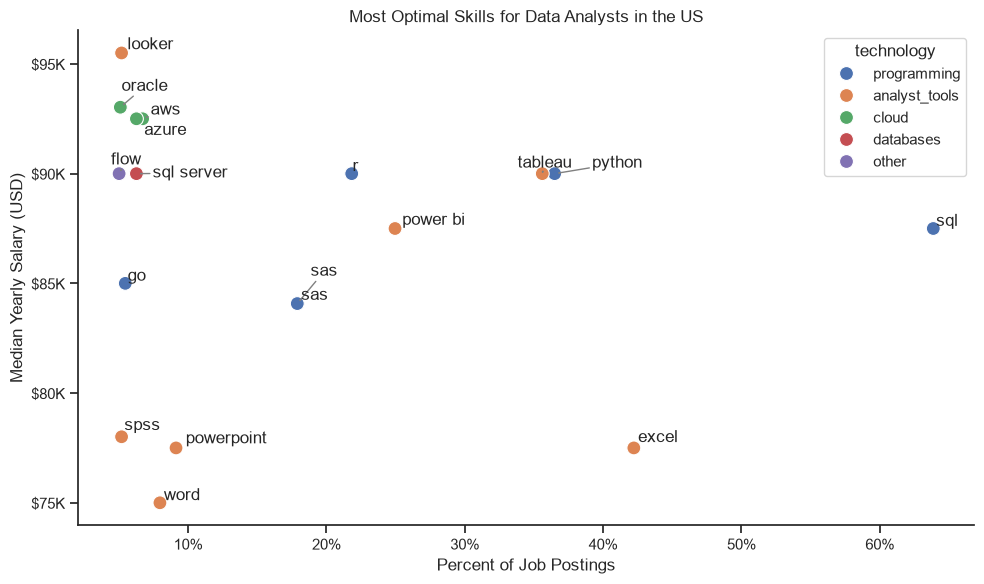

In [24]:
from adjustText import adjust_text

sns.set_theme(style='ticks')
plt.figure(figsize=(10, 6))

# correct column names and use string for hue
sns.scatterplot(
    data=df_plot,
    x='skills_percent',
    y='median_salary',
    hue='technology',
    s=100
)
sns.despine()

texts = []
# annotate using df_plot rows (skills column contains the skill name)
for i, row in df_plot.iterrows():
    texts.append(
        plt.text(
            row['skills_percent'],
            row['median_salary'],
            row['skills']
        )
    )

adjust_text(
    texts,
    arrowprops=dict(arrowstyle='->', color='gray')
)

plt.xlabel('Percent of Job Postings')
plt.ylabel('Median Yearly Salary (USD)')
plt.title('Most Optimal Skills for Data Analysts in the US')

from matplotlib.ticker import PercentFormatter

ax = plt.gca()
# x values are percentages (0-100), so set xmax=100
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
)

plt.tight_layout()
plt.show()